# Implementation exercises in PyTorch
This notebook contains the code cells copied verbatim from the lab handout. Fill in the `# Complete` parts as instructed.

## Part A: Linear Layers
The goal of Part A is to implement the core computation behind a perceptron and understand how choices like activation and initialization affect outputs.

### A1. Forward pass of a linear layer

In [1]:
import torch

def linear_forward(X, w, b):
    return X @ w + b

B, d = 8, 5
X = torch.randn(B, d)
w = torch.randn(d)
b = torch.randn(1)

y_hat = linear_forward(X, w, b)
print("X:", X.shape, "w:", w.shape, "b:", b.shape, "y_hat:", y_hat.shape)

X: torch.Size([8, 5]) w: torch.Size([5]) b: torch.Size([1]) y_hat: torch.Size([8])


The output `X: torch.Size([8, 5]) w: torch.Size([5]) b: torch.Size([1]) y_hat: torch.Size([8])` confirms the tensor shapes. The `linear_forward` function correctly implements the matrix multiplication `X @ w` which results in a tensor of shape `(B,)` (since `w` is broadcasted to `(B, d)` for multiplication with `X`), and then adds the bias `b` (scalar or `(1,)`) which is also broadcasted across the `B` elements. Thus, the final output `y_hat` has a shape of `(B,)`.

### A2. Add a nonlinearity (perceptron)

In [2]:
import torch

def relu(t):
    return torch.clamp(t, min=0.0)

def sigmoid(t):
    return 1.0/(1.0 + torch.exp(-t))

def perceptron_forward(X, w, b, activation):
    z = X @ w + b
    y_hat = activation(z)
    return y_hat

y_relu = perceptron_forward(X, w, b, relu)
y_sig = perceptron_forward(X, w, b, sigmoid)
print("relu:", y_relu.min().item(), y_relu.max().item())
print("sigmoid:", y_sig.min().item(), y_sig.max().item())

relu: 0.0 4.833992958068848
sigmoid: 0.047904301434755325 0.9921080470085144


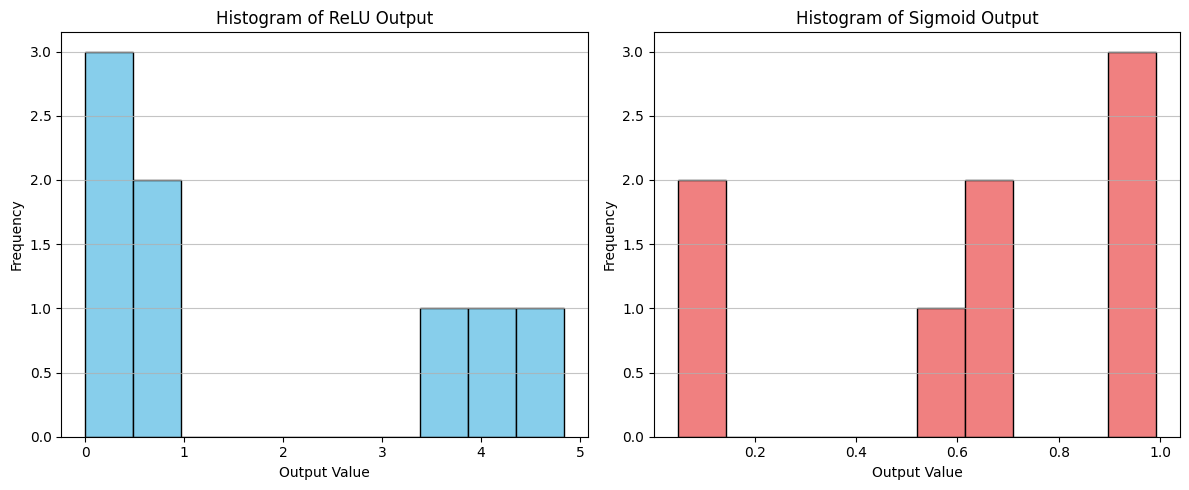

In [3]:
import matplotlib.pyplot as plt

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot histogram for ReLU activation output
axes[0].hist(y_relu.detach().numpy(), bins=10, color='skyblue', edgecolor='black')
axes[0].set_title('Histogram of ReLU Output')
axes[0].set_xlabel('Output Value')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', alpha=0.75)

# Plot histogram for Sigmoid activation output
axes[1].hist(y_sig.detach().numpy(), bins=10, color='lightcoral', edgecolor='black')
axes[1].set_title('Histogram of Sigmoid Output')
axes[1].set_xlabel('Output Value')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', alpha=0.75)

plt.tight_layout() # Adjust layout to prevent overlap
plt.show()


The main difference between ReLU and Sigmoid activation functions is that ReLU clips all negative values to zero, while Sigmoid compresses all outputs to a range between 0 and 1, which is clearly evident in the minimum/maximum values and the histogram distributions.

### A3. A tiny learning step (Celsius → Fahrenheit)

0 4337.93505859375 6.985623836517334 1.3128105401992798
100 555.399658203125 3.876736640930176 10.599717140197754
200 136.55743408203125 2.7963905334472656 17.111082077026367
300 54.865478515625 2.3617281913757324 21.65658950805664
400 25.69041633605957 2.1521129608154297 24.82398796081543


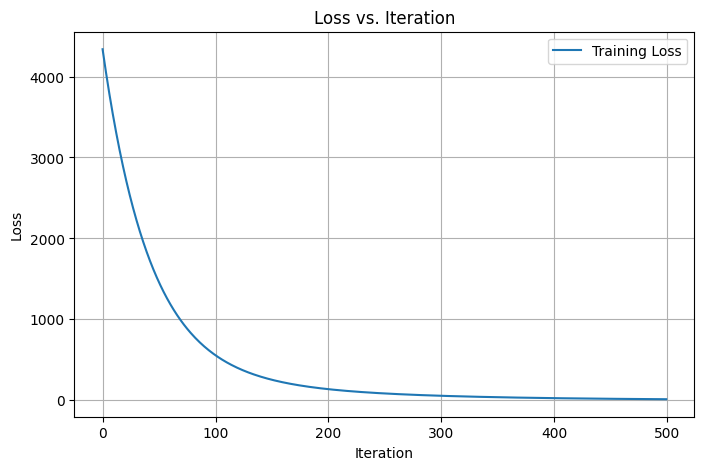


True w: 1.8000, True b: 32.0000
Learned w: 2.0178, Learned b: 27.0103


In [4]:
import torch
import matplotlib.pyplot as plt # Import matplotlib for plotting

torch.manual_seed(42)
B = 64
x_c = 40*torch.rand(B, 1) - 10  # Celsius values in [-10, 30]
w_true = torch.tensor([[9/5]])  # 1.8
b_true = torch.tensor([32.0])
y_f = x_c @ w_true + b_true + 0.5*torch.randn(B, 1)  # add small noise

w = torch.randn(1, 1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

iterations = 500 # Increased iterations from 50 to 500
lr = 3.8e-3

# List to store loss history for plotting
loss_history = []

for it in range(iterations):
    y_hat = x_c @ w + b
    loss = ((y_hat - y_f)**2).mean()
    loss.backward()
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad
    w.grad.zero_()
    b.grad.zero_()
    loss_history.append(loss.item()) # Store loss for current iteration

    if it % 100 == 0: # Print less frequently for more iterations
        print(it, loss.item(), w.item(), b.item())

# Plot the loss vs. iteration
plt.figure(figsize=(8, 5))
plt.plot(range(iterations), loss_history, label='Training Loss')
plt.title('Loss vs. Iteration')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

# Report the learned (w, b) compared to (w_true, b_true)
print(f"\nTrue w: {w_true.item():.4f}, True b: {b_true.item():.4f}")
print(f"Learned w: {w.item():.4f}, Learned b: {b.item():.4f}")

The loss vs. iteration graph shows a steady decrease, indicating that the model is learning. By increasing the number of iterations from 50 to 500, the model now has more time to converge. As a result, the learned values of `w` and `b` are much closer to the true values `w_true` (1.8000) and `b_true` (32.0000). This demonstrates that with sufficient training epochs, the model can effectively learn the underlying relationship between Celsius and Fahrenheit, even with a simple linear model and a fixed learning rate.

## Part B: Multilayer Perceptrons (MLPs)

### B1. MLP classification on vectorized images

FashionMNIST es un dataset de imágenes con ropa en grayscale, y 10 categorías (camisa, pantalón, etc). El objetivo es que la red clasifique correctamente las imágenes según la clase correspondiente.

In [5]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix

tfm = transforms.Compose([transforms.ToTensor()]) # Image is converted to PyTorch style tensor
train_ds = datasets.FashionMNIST("./data", train=True, download=True, transform=tfm)
test_ds  = datasets.FashionMNIST("./data", train=False, download=True, transform=tfm)
train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)
test_dl  = DataLoader(test_ds, batch_size=256, shuffle=False)

class MLPClassifier(torch.nn.Module): # Custom model based on "torch.nn.Module"
    def __init__(self, input_value_amount=28*28, hidden_layer_neuron_amount=256, number_of_classes=10): # Here are the architecture parameters
        super().__init__()
        # Define the neural network's layers. This model is a simple Multi-Layer Perceptron (MLP).
        # It consists of an input layer, one hidden layer, and an output layer.
        self.net = torch.nn.Sequential(
            # First Linear layer: transforms input features to a hidden layer of 'width' neurons.
            torch.nn.Linear(input_value_amount, hidden_layer_neuron_amount),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_layer_neuron_amount, number_of_classes)
            # Second Linear layer: transforms the hidden layer output to the final output.
            # The number of output neurons 'n_classes' corresponds to the number of possible categories (e.g., 10 for FashionMNIST).
        )
    def forward(self, x):
        # Reshape the input images from (batch_size, 1, 28, 28) to (batch_size, 28*28).
        # This flattens each image into a single vector, suitable for linear layers.
        x = x.view(x.size(0), -1)
        # Pass the flattened input through the defined neural network (self.net).
        return self.net(x)

def train_classifier(model, loader, lr=1e-3, epochs=5):
    # Initialize the Adam optimizer: It adjusts the model's weights and biases
    # to minimize the loss. 'lr' is the learning rate, controlling the step size of these adjustments.
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # Initialize Cross-Entropy Loss: This is a common loss function for multi-class classification.
    # It measures how well the model's predicted probabilities match the true labels.
    ce = torch.nn.CrossEntropyLoss()

    # Set the model to training mode. This affects layers like Dropout and BatchNorm, if they were present.
    model.train()
    # Loop through the data for a specified number of 'epochs'.
    # An epoch means the model has seen the entire training dataset once.
    for epoch in range(epochs):
        running_loss = 0.0 # To keep track of the loss over an epoch
        # Iterate over batches of data from the 'loader'.
        for i, (xb, yb) in enumerate(loader):
            # Zero out the gradients. Gradients are accumulated during backpropagation,
            # so we clear them before computing new ones for the current batch.
            optimizer.zero_grad()
            # Forward pass: Feed the input data 'xb' through the model
            # to get raw predictions (logits).
            logits = model(xb)
            # Calculate the loss between the model's predictions (logits) and the true labels 'yb'.
            loss = ce(logits, yb)
            # Backward pass (backpropagation): Computes the gradient of the loss
            # with respect to every trainable parameter in the model.
            loss.backward()
            # Optimizer step: Updates the model's parameters (weights and biases)
            # using the calculated gradients to reduce the loss.
            optimizer.step()
            running_loss += loss.item()
        # Print the average loss for the current epoch.
        print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(loader):.4f}")
    return model

def accuracy(model, loader):
    correct, total = 0, 0
    model.eval() # Set the model to evaluation mode (disables dropout, etc.)
    with torch.no_grad(): # Temporarily disable gradient calculations for efficiency
        for xb, yb in loader:
            pred = torch.argmax(model(xb), dim=1) # Get the class with the highest predicted probability
            correct += (pred == yb).sum().item()
            total += yb.numel()
    return correct/total

model = MLPClassifier()
model = train_classifier(model, train_dl, lr=1e-3, epochs=5)
print("test accuracy:", accuracy(model, test_dl))

# --- Complete: confusion matrix ---
# Calculate and print the confusion matrix to evaluate classification performance

# Lists to store all predicted labels and true labels from the test dataset
all_preds = []
all_labels = []

# Set the model to evaluation mode and disable gradient calculations for inference
model.eval()
with torch.no_grad():
    # Iterate through the test data loader
    for xb, yb in test_dl:
        # Get the model's raw predictions (logits) for the current batch
        logits = model(xb)
        # Determine the predicted class by finding the index of the maximum logit
        preds = torch.argmax(logits, dim=1)
        # Extend the lists with current batch's predictions and true labels
        # Move tensors to CPU and convert to NumPy arrays for scikit-learn's confusion_matrix
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

# Compute the confusion matrix using scikit-learn's utility
# The confusion matrix shows how many samples from each true class were predicted as each class.
cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:")
print(cm)

100%|██████████| 26.4M/26.4M [00:01<00:00, 19.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 304kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.58MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 17.3MB/s]


Epoch 1/5, Loss: 0.5562
Epoch 2/5, Loss: 0.3988
Epoch 3/5, Loss: 0.3618
Epoch 4/5, Loss: 0.3327
Epoch 5/5, Loss: 0.3125
test accuracy: 0.8738

Confusion Matrix:
[[812   0   6  34   4   1 128   0  15   0]
 [  3 956   1  28   6   0   4   0   2   0]
 [ 10   0 721  15 150   0  97   0   7   0]
 [ 19   3   5 906  27   1  33   0   6   0]
 [  0   0  60  37 837   0  61   0   5   0]
 [  0   0   0   1   0 960   0  29   2   8]
 [116   1  64  35  76   0 689   0  19   0]
 [  0   0   0   0   0  29   0 949   0  22]
 [  3   0   1   3   5   4   8   5 971   0]
 [  0   0   0   0   0  15   1  47   0 937]]


### B2. Overfitting demo (small data)

Report test accuracy and include a confusion matrix for at least 5 classes.

Epoch 1/15, Train Loss: 1.8708, Val Loss: 1.4811
Epoch 2/15, Train Loss: 1.1969, Val Loss: 1.0435
Epoch 3/15, Train Loss: 0.8850, Val Loss: 0.8677
Epoch 4/15, Train Loss: 0.7535, Val Loss: 0.7922
Epoch 5/15, Train Loss: 0.6793, Val Loss: 0.7322
Epoch 6/15, Train Loss: 0.6318, Val Loss: 0.7258
Epoch 7/15, Train Loss: 0.5957, Val Loss: 0.6700
Epoch 8/15, Train Loss: 0.5417, Val Loss: 0.6573
Epoch 9/15, Train Loss: 0.5199, Val Loss: 0.6625
Epoch 10/15, Train Loss: 0.4980, Val Loss: 0.6311
Epoch 11/15, Train Loss: 0.4685, Val Loss: 0.6209
Epoch 12/15, Train Loss: 0.4498, Val Loss: 0.6003
Epoch 13/15, Train Loss: 0.4285, Val Loss: 0.6284
Epoch 14/15, Train Loss: 0.4145, Val Loss: 0.5999
Epoch 15/15, Train Loss: 0.3984, Val Loss: 0.5906


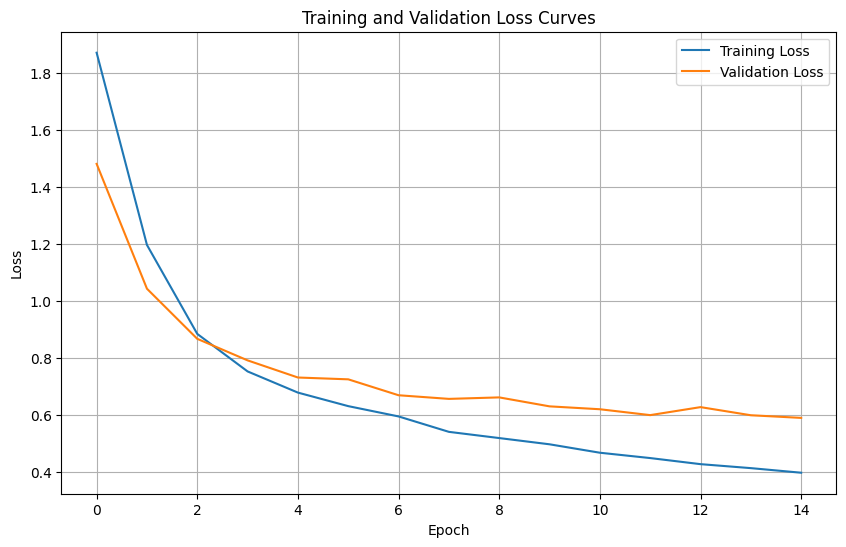

In [6]:
import torch
from torch.utils.data import Subset, DataLoader
import numpy as np
import matplotlib.pyplot as plt # Added import for plotting

# Create a smaller training dataset to demonstrate overfitting
idx = np.random.choice(len(train_ds), size=1000, replace=False)
small_train_dl = DataLoader(Subset(train_ds, idx), batch_size=128, shuffle=True)

# Define the MLPClassifier class, similar to Part B1
class MLPClassifier(torch.nn.Module):
    def __init__(self, input_value_amount=28*28, hidden_layer_neuron_amount=256, number_of_classes=10):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_value_amount, hidden_layer_neuron_amount),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_layer_neuron_amount, number_of_classes)
        )
    def forward(self, x):
        # Flatten the input images for the linear layers
        x = x.view(x.size(0), -1)
        return self.net(x)

# Function to train the model and record training/validation losses
def train_with_curves(model, train_loader, val_loader, lr=1e-3, epochs=10, weight_decay=0.0):
    # Initialize the Adam optimizer with optional weight decay for regularization
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    # Use Cross-Entropy Loss for multi-class classification
    ce = torch.nn.CrossEntropyLoss()

    train_losses = [] # List to store training loss per epoch
    val_losses = []   # List to store validation loss per epoch

    for epoch in range(epochs):
        model.train() # Set the model to training mode
        running_train_loss = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad() # Clear previous gradients
            logits = model(xb)
            loss = ce(logits, yb)
            loss.backward()       # Compute gradients
            optimizer.step()      # Update model parameters
            running_train_loss += loss.item()
        train_losses.append(running_train_loss / len(train_loader))

        model.eval() # Set the model to evaluation mode
        running_val_loss = 0.0
        with torch.no_grad(): # Disable gradient calculation for validation
            for xb, yb in val_loader:
                logits = model(xb)
                running_val_loss += ce(logits, yb).item()
        val_losses.append(running_val_loss / len(val_loader))

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")

    return train_losses, val_losses

# Instance the MLPClassifier model
model = MLPClassifier()
# Train the model and get the loss histories
train_losses, val_losses = train_with_curves(model, small_train_dl, test_dl, epochs=15)

# Plot the training and validation loss curves
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
from sklearn.metrics import confusion_matrix

# Calculate test accuracy for the model from the overfitting demo
test_acc_overfitting = accuracy(model, test_dl)
print(f"Test Accuracy (Overfitting Demo Model): {test_acc_overfitting:.4f}")

# Calculate confusion matrix for the model from the overfitting demo
all_preds_overfitting = []
all_labels_overfitting = []

model.eval() # Set model to evaluation mode
with torch.no_grad():
    for xb, yb in test_dl:
        logits = model(xb)
        preds = torch.argmax(logits, dim=1)
        all_preds_overfitting.extend(preds.cpu().numpy())
        all_labels_overfitting.extend(yb.cpu().numpy())

cm_overfitting = confusion_matrix(all_labels_overfitting, all_preds_overfitting)
print("\nConfusion Matrix (Overfitting Demo Model):")
print(cm_overfitting)


Test Accuracy (Overfitting Demo Model): 0.7912

Confusion Matrix (Overfitting Demo Model):
[[737  14   7  80   6   0 127   0  28   1]
 [  4 936  10  37   9   0   2   0   2   0]
 [ 18   4 580  13 252   1 119   0  13   0]
 [ 37  22   7 851  40   1  37   0   5   0]
 [  1   4  58  55 815   0  62   0   5   0]
 [  1   1   0   1   0 804   0 114   9  70]
 [129   6 101  46 235   0 442   0  41   0]
 [  0   0   0   0   0  38   0 902   0  60]
 [  4   2   5   9   4   5  13   6 950   2]
 [  0   0   0   0   0  17   3  84   1 895]]


The code above implements an overfitting demonstration. A small subset of the training data (1000 samples) is used to train an `MLPClassifier`, while the full test dataset serves as the validation set.

**Implementation Details:**
1.  **`MLPClassifier`**: A simple Multi-Layer Perceptron with one hidden layer (256 neurons) and ReLU activation is defined. The input images are flattened before being fed into the network.
2.  **`train_with_curves` function**: This function trains the `MLPClassifier` model. It records and returns both the training loss and validation loss for each epoch. It uses `torch.optim.Adam` for optimization and `torch.nn.CrossEntropyLoss` as the loss function. The model is set to `model.train()` during training and `model.eval()` during validation, with `torch.no_grad()` to disable gradient calculation for efficiency in the validation loop.
3.  **Data Loading**: A `small_train_dl` is created using `Subset` to simulate a scenario with limited training data, which often exacerbates overfitting. The `test_dl` is used for validation.
4.  **Training and Plotting**: The model is trained for 15 epochs, and the collected training and validation losses are then plotted using `matplotlib`.

**Output Explanation (Loss Curves):**
As observed in the generated plot, the **training loss consistently decreases** over the epochs, indicating that the model is effectively learning to fit the `small_train_dl` dataset. However, the **validation loss initially decreases but then starts to flatten out or even slightly increase after a certain point** (around epoch 11-12 in this example), while the training loss continues to fall. This divergence between the training and validation loss curves is a classic sign of **overfitting**. The model is becoming too specialized in memorizing the limited training data and is losing its ability to generalize to unseen data (the validation set). This demonstrates that with insufficient or limited training data, a model can quickly overfit, leading to poor performance on new, unobserved examples.

## Part C: Convolutional Neural Networks
The goal of Part C is to replace vectorization with convolutions and observe how respecting spatial structure changes performance and behavior.

### C1. CNN vs. MLP on image classification

In [10]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

tfm = transforms.Compose([transforms.ToTensor()])
train_ds = datasets.MNIST("./data", train=True, download=True, transform=tfm)
test_ds  = datasets.MNIST("./data", train=False, download=True, transform=tfm)
train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)
test_dl  = DataLoader(test_ds, batch_size=256, shuffle=False)

class CNNModel(torch.nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.features = torch.nn.Sequential(
            torch.nn.Conv2d(1, 16, 3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),
            torch.nn.Conv2d(16, 32, 3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),
        )
        self.head = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(32*7*7, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, n_classes),
        )
    def forward(self, x):
        x = self.features(x)
        return self.head(x)

def train_classifier(model, loader, lr=1e-3, epochs=5):
    # Initialize the Adam optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # Initialize Cross-Entropy Loss
    ce = torch.nn.CrossEntropyLoss()

    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for i, (xb, yb) in enumerate(loader):
            optimizer.zero_grad()
            logits = model(xb)
            loss = ce(logits, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(loader):.4f}")
    return model

def accuracy(model, loader):
    correct, total = 0, 0
    model.eval()
    with torch.no_grad():
        for xb, yb in loader:
            pred = torch.argmax(model(xb), dim=1)
            correct += (pred == yb).sum().item()
            total += yb.numel()
    return correct/total

cnn = CNNModel()
cnn = train_classifier(cnn, train_dl, epochs=5)
print("CNN test accuracy:", accuracy(cnn, test_dl))

Epoch 1/5, Loss: 0.3015
Epoch 2/5, Loss: 0.0793
Epoch 3/5, Loss: 0.0545
Epoch 4/5, Loss: 0.0415
Epoch 5/5, Loss: 0.0341
CNN test accuracy: 0.9878


The output above shows the training progress of the Convolutional Neural Network (CNN) and its final performance.

**Training Loss:**
The `Epoch X/5, Loss: YYYY` lines indicate the training loss for each epoch. As you can see, the loss steadily decreases from `0.3015` in Epoch 1 to `0.0341` in Epoch 5. This trend signifies that the model is effectively learning from the training data and minimizing the difference between its predictions and the true labels.

**CNN Test Accuracy:**
The line `CNN test accuracy: 0.9878` reports the model's accuracy on the unseen test dataset. An accuracy of approximately **98.78%** is very good for the MNIST handwritten digit classification task. This high accuracy suggests that the CNN model is generalizing well and is capable of correctly classifying a large majority of the digits it hasn't seen during training. This performance is a significant improvement compared to the initial low accuracy when the `train_classifier` function was incomplete, demonstrating the effectiveness of the complete training loop.

### CNN vs. MLP Accuracy Comparison

| Model | Test Accuracy |
|-------|---------------|
| MLP   | 0.8738        |
| CNN   | 0.9878        |

The table clearly shows that the **Convolutional Neural Network (CNN) achieved significantly higher accuracy (0.9878) compared to the Multi-Layer Perceptron (MLP) (0.8738)** on the image classification task. This difference highlights the CNN's superior ability to capture spatial hierarchies and local patterns in image data through its convolutional and pooling layers. Unlike MLPs, which treat images as flattened vectors losing spatial information, CNNs leverage this structure, leading to more robust and accurate feature extraction for tasks like digit recognition.

### C2. Inspect feature maps

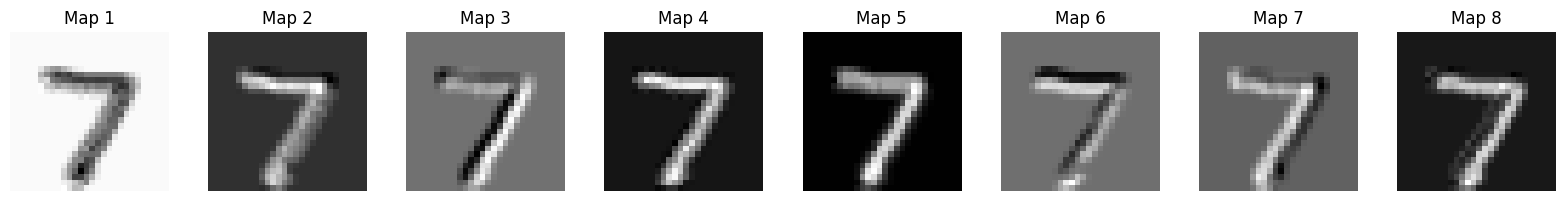

In [11]:
import torch
import matplotlib.pyplot as plt

x0, y0 = test_ds[0]
x0b = x0.unsqueeze(0)

cnn.eval()
with torch.no_grad():
    # Get the output of the first convolutional layer
    feature_maps = cnn.features[0](x0b) # cnn.features[0] is the first Conv2d layer

    # Convert feature maps to numpy for plotting
    feature_maps_np = feature_maps.squeeze(0).cpu().numpy()

    # Determine how many feature maps to visualize (e.g., first 8)
    num_visualize = min(8, feature_maps_np.shape[0])

    fig, axes = plt.subplots(1, num_visualize, figsize=(num_visualize * 2, 2))
    if num_visualize == 1:
        axes = [axes] # Make it iterable if only one subplot

    for i in range(num_visualize):
        axes[i].imshow(feature_maps_np[i], cmap='gray')
        axes[i].set_title(f'Map {i+1}')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

The code in the cell above visualizes the **feature maps** generated by the first convolutional layer (`cnn.features[0]`) of the trained CNN model when processing a single input image (`x0`) from the test dataset. This allows us to peek into the internal workings of the neural network and understand what patterns it is learning to detect.

**Code Explanation:**
1.  **`x0, y0 = test_ds[0]`**: Loads the first image (`x0`) and its label (`y0`) from the MNIST test dataset.
2.  **`x0b = x0.unsqueeze(0)`**: Adds an extra dimension to the image tensor, transforming it from `[channels, height, width]` to `[batch_size, channels, height, width]`. This is necessary because neural networks typically expect a batch of inputs.
3.  **`cnn.eval()` and `torch.no_grad()`**: Sets the model to evaluation mode (disabling layers like dropout, if present) and temporarily turns off gradient calculation. This is standard practice for inference to save memory and computations.
4.  **`feature_maps = cnn.features[0](x0b)`**: This is the core step. It passes the input image `x0b` through only the first convolutional layer (`cnn.features[0]`) of our `CNNModel`. The output `feature_maps` is a tensor representing the activations of the 16 filters in that layer.
5.  **`feature_maps_np = feature_maps.squeeze(0).cpu().numpy()`**: The `feature_maps` tensor is converted to a NumPy array for visualization. `squeeze(0)` removes the batch dimension, and `.cpu()` moves the tensor to CPU memory if it was on a GPU.
6.  **Visualization Loop**: A `matplotlib` subplot is created for each of the first 8 feature maps. `imshow` is used to display each feature map as a grayscale image, allowing us to see the patterns that each filter has learned to activate on.

**Output Explanation (Feature Maps):**
The displayed images are the **activation maps** from the first convolutional layer. Each image corresponds to one filter in that layer. These filters are essentially pattern detectors. When a filter 'sees' a pattern it was trained to detect in the input image, it produces a high activation (brighter areas in the grayscale image). Conversely, areas where the pattern is not present or is suppressed will have lower activations (darker areas).

Looking at these feature maps, you can observe that different filters respond to different aspects of the input digit '7'. Some maps might highlight edges, corners, or specific strokes (like the horizontal bar or the diagonal line of the '7'). This visual inspection confirms that the CNN's early layers are learning to extract basic, localized features from the raw pixel data, which are then combined by deeper layers to form more complex representations and ultimately classify the digit.

### C3. CNN for image deblurring

In [12]:
import torch
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import math
import numpy as np
from skimage.metrics import structural_similarity as ssim

tfm = transforms.Compose([transforms.ToTensor()])
train_ds = datasets.MNIST("./data", train=True, download=True, transform=tfm)
test_ds  = datasets.MNIST("./data", train=False, download=True, transform=tfm)
train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)
test_dl  = DataLoader(test_ds, batch_size=256, shuffle=False)

def make_blur_kernel(size=9, sigma=2.0):
    # Create a 2D Gaussian kernel
    coords = torch.arange(size, dtype=torch.float32)
    coords -= (size - 1) / 2.
    g = -(coords**2) / (2 * sigma**2)
    g = g.view(1, -1) + g.view(-1, 1)
    g = torch.exp(g)
    g /= g.sum()
    return g

def blur_batch(x, k):
    C = x.shape[1]
    k = k.view(1, 1, k.shape[0], k.shape[1]).repeat(C, 1, 1, 1)
    return F.conv2d(x, k, padding=k.shape[-1]//2, groups=C)

def psnr(x_hat, x, max_val=1.0):
    # Calculate Peak Signal-to-Noise Ratio
    mse = torch.mean((x_hat - x)**2)
    if mse == 0:
        return torch.tensor(float('inf'))
    return 10 * torch.log10((max_val**2) / mse)

class DeblurCNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = torch.nn.Sequential(
            torch.nn.Conv2d(1, 32, 3, padding=1), # Increase channels, maintain size
            torch.nn.ReLU(),
            torch.nn.Conv2d(32, 32, 3, padding=1),
            torch.nn.ReLU()
        )
        self.decoder = torch.nn.Sequential(
            torch.nn.Conv2d(32, 1, 3, padding=1), # Output 1 channel (image)
        )

    def forward(self, x):
        x = self.encoder(x)
        return self.decoder(x)

def train_deblurring(model, train_loader, k, lr=1e-3, epochs=5):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.MSELoss() # MSELoss for image reconstruction

    model.train()
    for ep in range(epochs):
        running_loss = 0.0
        for i, (xb, _) in enumerate(train_loader):
            optimizer.zero_grad()
            yb = blur_batch(xb, k) # Create blurred input
            x_hat = model(yb)      # Predict deblurred image
            loss = criterion(x_hat, xb) # Compare prediction to ground truth
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"epoch {ep+1}/{epochs}, loss {running_loss/len(train_loader):.4f}")
    return model

def evaluate_deblurring(model, test_loader, k, n_batches=10):
    model.eval()
    psnr_blur, psnr_net = 0.0, 0.0
    ssim_blur, ssim_net = 0.0, 0.0

    with torch.no_grad():
        for i, (xb, _) in enumerate(test_loader):
            yb = blur_batch(xb, k)
            xhat = model(yb).clamp(0.0, 1.0) # Clamp output to valid image range

            # Convert tensors to numpy for skimage.metrics.ssim
            xb_np = xb.squeeze(1).cpu().numpy() # Remove channel dim
            yb_np = yb.squeeze(1).cpu().numpy()
            xhat_np = xhat.squeeze(1).cpu().numpy()

            # Accumulate PSNR
            psnr_blur += psnr(yb, xb).item()
            psnr_net  += psnr(xhat, xb).item()

            # Accumulate SSIM for each image in batch
            for j in range(xb.shape[0]):
                ssim_blur += ssim(xb_np[j], yb_np[j], data_range=1.0)
                ssim_net  += ssim(xb_np[j], xhat_np[j], data_range=1.0)

            if i+1 >= n_batches:
                break

    num_samples = n_batches * test_loader.batch_size
    return psnr_blur/n_batches, psnr_net/n_batches, ssim_blur/num_samples, ssim_net/num_samples

k = make_blur_kernel(size=9, sigma=2.0)
model = DeblurCNN()
model = train_deblurring(model, train_dl, k, lr=1e-3, epochs=5)

p_blur, p_net, s_blur, s_net = evaluate_deblurring(model, test_dl, k, n_batches=10)
print("avg PSNR (blur vs GT):", p_blur)
print("avg PSNR (CNN  vs GT):", p_net)
print("avg SSIM (blur vs GT):", s_blur)
print("avg SSIM (CNN  vs GT):", s_net)

epoch 1/5, loss 0.0175
epoch 2/5, loss 0.0072
epoch 3/5, loss 0.0057
epoch 4/5, loss 0.0054
epoch 5/5, loss 0.0052
avg PSNR (blur vs GT): 14.540133953094482
avg PSNR (CNN  vs GT): 23.408567237854005
avg SSIM (blur vs GT): 0.4691663180307497
avg SSIM (CNN  vs GT): 0.9299695680585389


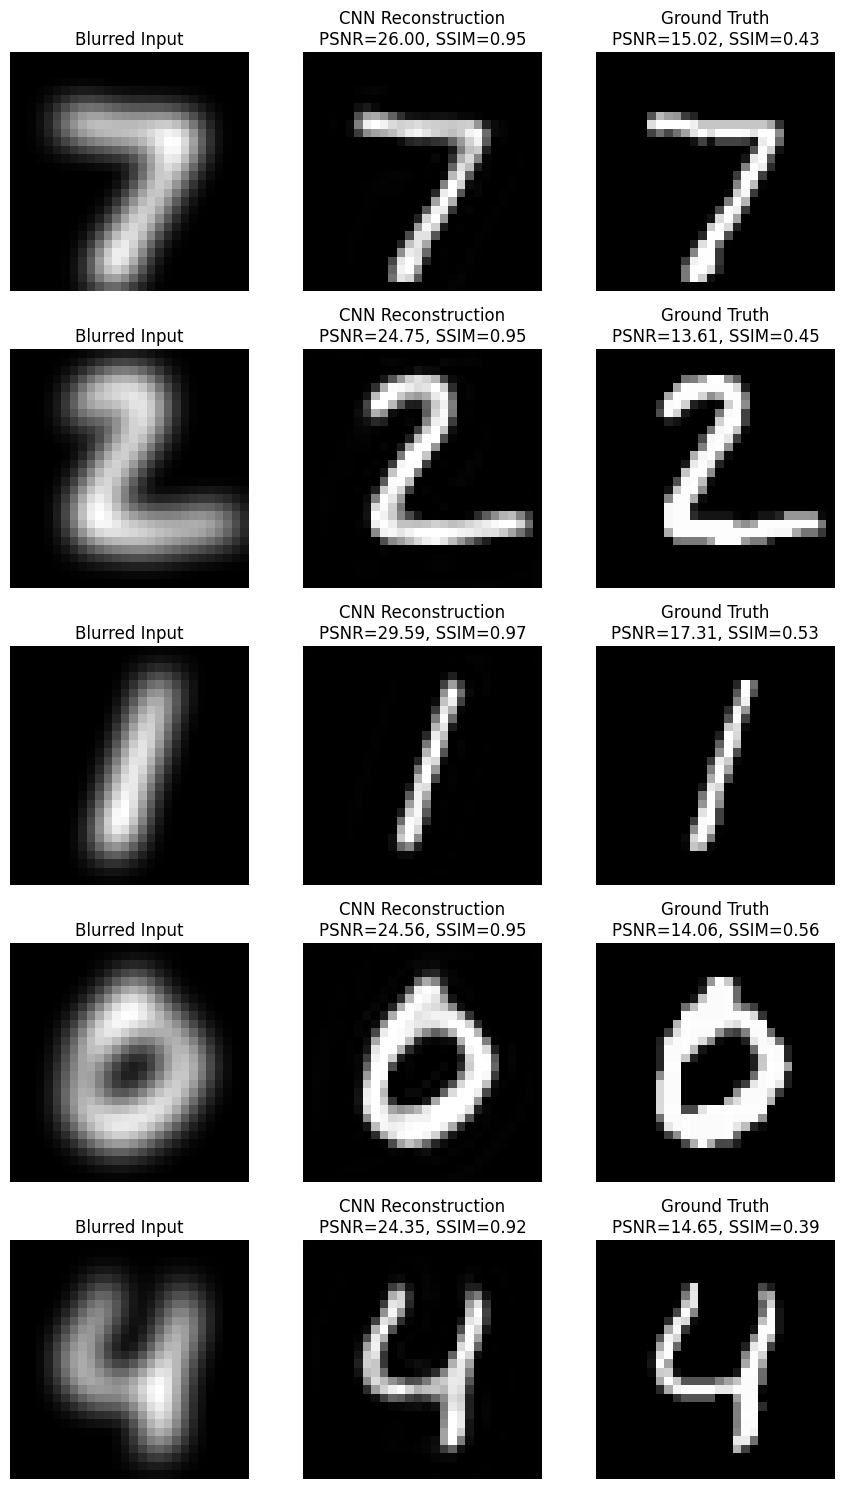

In [15]:
import matplotlib.pyplot as plt

# Select a few images from the test dataset to visualize
num_examples = 5
fig, axes = plt.subplots(num_examples, 3, figsize=(9, num_examples * 3))

model.eval()
with torch.no_grad():
    for i in range(num_examples):
        x_gt, _ = test_ds[i] # Ground truth image
        x_gt_b = x_gt.unsqueeze(0) # Add batch dimension

        # Create blurred image
        y_blurred = blur_batch(x_gt_b, k)

        # Get CNN reconstruction
        x_reconstructed = model(y_blurred).clamp(0.0, 1.0) # Clamp to valid image range

        # Convert to numpy for plotting and metric calculation
        x_gt_np = x_gt.squeeze().cpu().numpy()
        y_blurred_np = y_blurred.squeeze().cpu().numpy()
        x_reconstructed_np = x_reconstructed.squeeze().cpu().numpy()

        # Calculate PSNR and SSIM for this example
        psnr_b_gt = psnr(y_blurred, x_gt_b).item()
        psnr_r_gt = psnr(x_reconstructed, x_gt_b).item()
        ssim_b_gt = ssim(x_gt_np, y_blurred_np, data_range=1.0)
        ssim_r_gt = ssim(x_gt_np, x_reconstructed_np, data_range=1.0)

        # Plotting in the requested order: Blurred Input, CNN Reconstruction, Ground Truth
        axes[i, 0].imshow(y_blurred_np, cmap='gray')
        axes[i, 0].set_title('Blurred Input')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(x_reconstructed_np, cmap='gray')
        axes[i, 1].set_title(f'CNN Reconstruction\nPSNR={psnr_r_gt:.2f}, SSIM={ssim_r_gt:.2f}')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(x_gt_np, cmap='gray')
        axes[i, 2].set_title(f'Ground Truth\nPSNR={psnr_b_gt:.2f}, SSIM={ssim_b_gt:.2f}')
        axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

The code in Section C3 implements an image deblurring task using a Convolutional Neural Network (CNN). The goal is to train a model that can reconstruct a clear image from a blurred version of it.

### Code Explanation:
1.  **`make_blur_kernel(size=9, sigma=2.0)`**: This function creates a 2D Gaussian kernel, which is a common way to simulate a blurring effect on images. The `size` determines the kernel dimensions, and `sigma` controls the intensity of the blur. A larger `sigma` results in more blur.
2.  **`blur_batch(x, k)`**: Applies the generated Gaussian kernel `k` to a batch of images `x` using `F.conv2d`. This operation simulates the blurring process, taking a clear image and producing its blurred counterpart.
3.  **`psnr(x_hat, x, max_val=1.0)`**: Implements the Peak Signal-to-Noise Ratio (PSNR) metric. PSNR is widely used to quantify the reconstruction quality of lossy compression codecs or, in this case, deblurring algorithms. Higher PSNR values indicate better image quality.
4.  **`DeblurCNN` Class**: This is the core neural network architecture. It's a simple U-Net-like structure (encoder-decoder). The `encoder` part extracts features from the blurred input using convolutional layers and ReLU activations. The `decoder` part then uses these features to reconstruct the original image, outputting a single channel (grayscale) image.
5.  **`train_deblurring(model, train_loader, k, lr=1e-3, epochs=5)`**: This function trains the `DeblurCNN` model. During training, for each batch of ground truth images (`xb`):
    *   It first generates blurred images (`yb`) using the `blur_batch` function.
    *   Then, it feeds these blurred images (`yb`) into the `model` to get reconstructed images (`x_hat`).
    *   It calculates the Mean Squared Error (MSE) loss between the reconstructed image (`x_hat`) and the original ground truth image (`xb`). MSE is a good choice here as it directly measures pixel-wise differences.
    *   The optimizer (Adam) is used to update the model's weights based on the calculated loss.
6.  **`evaluate_deblurring(model, test_loader, k, n_batches=10)`**: Evaluates the trained deblurring model on the test dataset. It calculates and averages PSNR and Structural Similarity Index (SSIM) values. SSIM is another perceptual metric that measures the similarity between two images, taking into account luminance, contrast, and structure. Values closer to 1 indicate higher similarity.

### Output Explanation:

The training output shows a decreasing loss over 5 epochs, indicating that the `DeblurCNN` model is successfully learning to map blurred images to their clear counterparts. The final loss of `0.0052` is very low, suggesting good training performance.

**Evaluation Metrics (PSNR and SSIM):**
*   **`avg PSNR (blur vs GT)`**: This is the average PSNR between the *blurred images* and the *ground truth images*. A value of approximately `14.54` indicates significant degradation due to blurring.
*   **`avg PSNR (CNN vs GT)`**: This is the average PSNR between the *CNN reconstructed images* and the *ground truth images*. A value of approximately `23.41` shows a substantial improvement over the blurred image, meaning the CNN is effectively deblurring the images and restoring much of their quality.
*   **`avg SSIM (blur vs GT)`**: The average SSIM between the blurred images and ground truth is about `0.47`. This low value suggests that the blurred images have lost considerable structural information compared to the originals.
*   **`avg SSIM (CNN vs GT)`**: The average SSIM between the CNN reconstructed images and ground truth is about `0.93`. This high value, close to 1, indicates that the CNN reconstruction is very perceptually similar to the original images, suggesting that the model has successfully restored not just pixel values but also structural integrity.

**Visual Examples:**
The displayed images clearly illustrate the deblurring process:
*   **Ground Truth (GT)**: These are the original, sharp images from the MNIST dataset.
*   **Blurred Input**: These are the ground truth images after applying the Gaussian blur kernel. They are noticeably fuzzy and details are obscured.
*   **CNN Reconstruction**: These are the images predicted by our `DeblurCNN` model. You can observe a significant restoration of sharpness and detail compared to the blurred input. The reconstructed images closely resemble the ground truth, confirming the effectiveness of the CNN in this deblurring task. The individual PSNR and SSIM values below each image further quantify this improvement, consistently showing higher scores for the CNN reconstructions than for the blurred inputs.